# 📥 01 — Ingesta y Validación de Datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive montado')

Mounted at /content/drive
✅ Drive montado


In [2]:
%%capture
!pip install lightgbm==4.6.0 optuna scikit-learn pandas numpy mlflow
!pip install fastapi uvicorn nest-asyncio pyngrok evidently joblib matplotlib seaborn
print('OK')

In [3]:
import json, os, glob, hashlib
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
from datetime import datetime

BASE_DRIVE = '/content/drive/MyDrive/1. MAESTRÍA CIENCIA DE DATOS/ENTRENAMIENTO PRÁCTICO'

# Cargar config guardada por 00_setup, o definirla si no existe
config_path = f'{BASE_DRIVE}/pipeline_config.json'
if os.path.exists(config_path):
    with open(config_path) as f:
        CONFIG = json.load(f)
    print('✅ Config cargada desde archivo')
else:
    # Definir directamente si 00_setup no se ejecutó antes
    CONFIG = {
        'dir_raw_data'     : f'{BASE_DRIVE}/Data Cruda',
        'dir_training_data': f'{BASE_DRIVE}/Data Entrenamiento',
        'dir_processed'    : f'{BASE_DRIVE}/Data Preprocesada',
        'train_path'       : f'{BASE_DRIVE}/Data Preprocesada/training_data/preprocessed/train_vars_extrac.csv',
        'test_path'        : f'{BASE_DRIVE}/Data Preprocesada/training_data/preprocessed/test_vars_extrac.csv',
        'model_dir'        : f'{BASE_DRIVE}/Modelo',
        'model_path'       : f'{BASE_DRIVE}/Modelo/lgbm_model.pkl',
        'metadata_path'    : f'{BASE_DRIVE}/Modelo/lgbm_metadata.json',
        'mlflow_uri'       : f'{BASE_DRIVE}/mlruns',
        'experiment_name'  : 'campana_credito_propension',
        'monitor_dir'      : f'{BASE_DRIVE}/monitoreo',
        'target_col'       : 'target',
        'id_cols'          : ['partition','key_value','codunicocli',
                              'fch_creacion','p_fecinformacion','seg_un'],
        'score_col'        : 'prob_value_contact',
    }
    print('⚠️ Config definida localmente (ejecuta 00_setup para persistirla)')

mlflow.set_tracking_uri(CONFIG['mlflow_uri'])
mlflow.set_experiment(CONFIG['experiment_name'])
TARGET_COL = CONFIG['target_col']
print(f'✅ MLflow listo | Experimento: {CONFIG["experiment_name"]}')

✅ Config cargada desde archivo


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


✅ MLflow listo | Experimento: campana_credito_propension


## 1. Ingesta de Archivos Crudos

In [4]:
# Listar CSVs en Data Cruda
raw_files = sorted(glob.glob(os.path.join(CONFIG['dir_raw_data'], '*.csv')))

if not raw_files:
    raise FileNotFoundError(
        f"No se encontraron CSVs en: {CONFIG['dir_raw_data']}\n"
        "Verifica que la ruta sea correcta ejecutando:\n"
        "  os.listdir(CONFIG['dir_raw_data'])"
    )

print(f'📂 Archivos encontrados: {len(raw_files)}')
for f in raw_files:
    mb = os.path.getsize(f) / 1e6
    print(f'   {os.path.basename(f):25s} {mb:7.1f} MB')

📂 Archivos encontrados: 10
   p10_extrac.csv              130.3 MB
   p1_extrac.csv               134.6 MB
   p2_extrac.csv               135.9 MB
   p3_extrac.csv               132.9 MB
   p4_extrac.csv               125.2 MB
   p5_extrac.csv               121.9 MB
   p6_extrac.csv                97.5 MB
   p7_extrac.csv               100.6 MB
   p8_extrac.csv                99.0 MB
   p9_extrac.csv               106.6 MB


In [5]:
# Cargar muestra + calcular hashes (trazabilidad)
SAMPLE_ROWS = 50_000

def file_md5(fpath):
    h = hashlib.md5()
    with open(fpath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''): h.update(chunk)
    return h.hexdigest()

dfs, file_hashes = [], {}
for fpath in raw_files:
    df_tmp = pd.read_csv(fpath, nrows=SAMPLE_ROWS)
    df_tmp['_source'] = os.path.basename(fpath)
    dfs.append(df_tmp)
    file_hashes[os.path.basename(fpath)] = file_md5(fpath)[:12]

df_raw = pd.concat(dfs, ignore_index=True)
null_pct    = df_raw.isnull().sum() / len(df_raw) * 100
target_rate = df_raw[TARGET_COL].mean() if TARGET_COL in df_raw.columns else None

print(f'✅ Muestra: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'   Columnas con nulos: {(null_pct > 0).sum()}')
if target_rate is not None:
    print(f'   Tasa positivos: {target_rate:.4f} ({target_rate*100:.1f}%)')

✅ Muestra: 500,000 filas × 70 columnas
   Columnas con nulos: 43
   Tasa positivos: 0.0337 (3.4%)


## 2. Visualización EDA

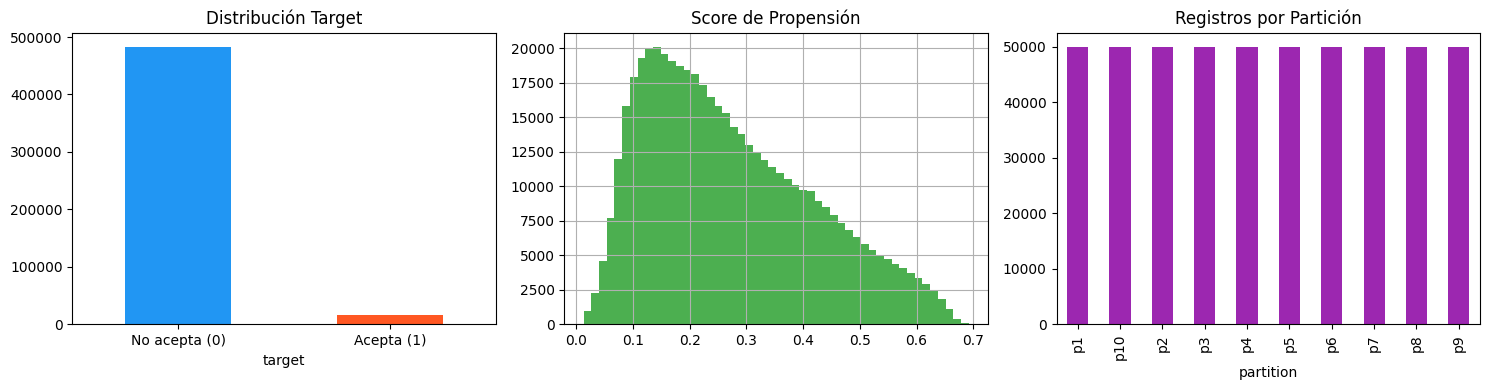

✅ EDA generado


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if TARGET_COL in df_raw.columns:
    df_raw[TARGET_COL].value_counts().plot(
        kind='bar', ax=axes[0], color=['#2196F3','#FF5722'])
    axes[0].set_title('Distribución Target')
    axes[0].set_xticklabels(['No acepta (0)','Acepta (1)'], rotation=0)

if 'prob_value_contact' in df_raw.columns:
    df_raw['prob_value_contact'].hist(bins=50, ax=axes[1], color='#4CAF50')
    axes[1].set_title('Score de Propensión')

df_raw['partition'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color='#9C27B0')
axes[2].set_title('Registros por Partición')

plt.tight_layout()
plt.savefig('/tmp/ingesta_eda.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ EDA generado')

## 3. Registro en MLflow

In [7]:
with mlflow.start_run(run_name='01_ingesta') as run:
    mlflow.log_param('n_archivos',    len(raw_files))
    mlflow.log_param('sample_rows',   SAMPLE_ROWS)
    mlflow.log_param('timestamp',     datetime.now().strftime('%Y-%m-%d %H:%M'))
    mlflow.log_metric('n_filas',      len(df_raw))
    mlflow.log_metric('n_columnas',   df_raw.shape[1])
    mlflow.log_metric('pct_nulos',    float(null_pct.mean()))
    if target_rate:
        mlflow.log_metric('target_rate', float(target_rate))
    for fname, md5 in list(file_hashes.items())[:5]:
        mlflow.log_param(f'md5_{fname[:8]}', md5)
    mlflow.log_artifact('/tmp/ingesta_eda.png')
    print(f'✅ Ingesta registrada → Run ID: {run.info.run_id}')

print('   ➡️  Siguiente: 02_preprocesamiento.ipynb')

✅ Ingesta registrada → Run ID: d6062ed7bef145ad9a8bf9f46b7a92b5
   ➡️  Siguiente: 02_preprocesamiento.ipynb
